# 06 — Task 2.3: Transformer Fine-tuning
Fine-tunes `distilbert-base-uncased` on the IMDB train set and evaluates on the test set.

Note: The outputs shown in the notebook were generated on a MacBook M5 Pro with 16 GB of RAM.

In [ ]:
import sys, os
sys.path.insert(0, '..')

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset
import evaluate

from src.utils import load_data, evaluate_predictions, save_results

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

train_texts, train_labels = load_data('train')
test_texts,  test_labels  = load_data('test')
print(f'Train: {len(train_texts):,} | Test: {len(test_texts):,}')

Device: cpu
Train: 41,750 | Test: 2,000


## 1. Label encoding

In [12]:
LABEL2ID = {'neg': 0, 'pos': 1}
ID2LABEL = {0: 'neg', 1: 'pos'}

train_y = [LABEL2ID[l] for l in train_labels]
test_y  = [LABEL2ID[l] for l in test_labels]

## 2. Tokenise

In [ ]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenise_batch(batch):
    return tokenizer(batch['text'], truncation=True, max_length=512)

train_ds = Dataset.from_dict({'text': train_texts, 'label': train_y})
test_ds  = Dataset.from_dict({'text': test_texts,  'label': test_y})

train_ds = train_ds.map(tokenise_batch, batched=True, remove_columns=['text'])
test_ds  = test_ds.map(tokenise_batch,  batched=True, remove_columns=['text'])

print('Tokenisation complete.')
print(f'Train features: {train_ds.features}')

Map:   0%|          | 0/41750 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenisation complete.
Train features: {'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## 3. Model

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(device)
print(f'Device: {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device: cpu
Parameters: 66,955,010


## 4. Training

In [ ]:
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir='../models/distilbert_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=200,
    seed=42,
    report_to='none',
    use_cpu=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.179446,0.300629,0.901000
2,0.131056,0.175017,0.947000
3,0.065414,0.208224,0.947500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=7830, training_loss=0.1458564306127614, metrics={'train_runtime': 23573.1616, 'train_samples_per_second': 5.313, 'train_steps_per_second': 0.332, 'total_flos': 1.4225049378581208e+16, 'train_loss': 0.1458564306127614, 'epoch': 3.0})

## 5. Evaluate on test set

In [16]:
preds_output = trainer.predict(test_ds)
pred_ids = np.argmax(preds_output.predictions, axis=-1)
pred_labels = [ID2LABEL[i] for i in pred_ids]

metrics = evaluate_predictions(test_labels, pred_labels)
print('Fine-tuned DistilBERT:', metrics)

save_results(
    task='2.3',
    approach='DistilBERT (fine-tuned)',
    metrics=metrics,
    preprocessing='truncation to 512 tokens, dynamic padding per batch',
    notes='distilbert-base-uncased, 3 epochs, lr=2e-5, bs=16'
)

Fine-tuned DistilBERT: {'accuracy': 0.9475, 'precision': 0.9508, 'recall': 0.9462, 'f1': 0.9485}
Saved: [2.3] DistilBERT (fine-tuned) — acc=0.9475 f1=0.9485


## 6. Training curve

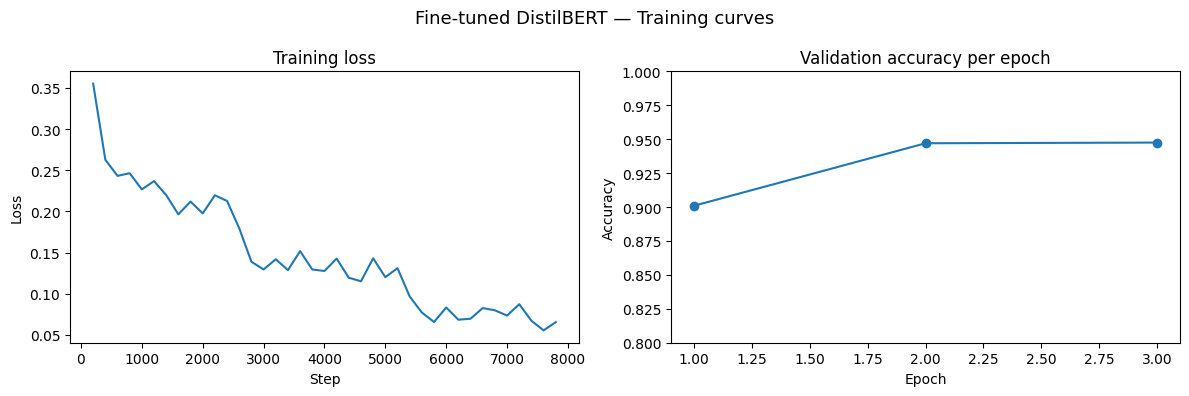

Final test accuracy: 0.9475 | F1: 0.9485


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

log_history = pd.DataFrame(trainer.state.log_history)

train_loss = log_history[log_history['loss'].notna()][['step', 'loss']]
eval_acc   = log_history[log_history['eval_accuracy'].notna()][['epoch', 'eval_accuracy']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_loss['step'], train_loss['loss'])
axes[0].set_title('Training loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')

axes[1].plot(eval_acc['epoch'], eval_acc['eval_accuracy'], marker='o')
axes[1].set_title('Validation accuracy per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.8, 1.0)

plt.suptitle('Fine-tuned DistilBERT — Training curves', fontsize=13)
plt.tight_layout()
plt.savefig('../results/fig_finetuning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final test accuracy: {metrics['accuracy']} | F1: {metrics['f1']}")